<a href="https://colab.research.google.com/github/mromanenko095/sympy-solutions/blob/main/10_curved_mirrors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Криволинейные зеркала

Выполнил: Романенко Михаил Юрьевич, 409460

Требуется найти кривую, после отражения от которой параллельный пучок сходится (фокусируется) в одной общей точке - фокусе. Пусть исходный пучок состоит из вертикальных лучей. Введем систему координат, ось $Oy$ направим против направления лучей (лучи падают на искомую кривую сверху вниз). Считаем, что точка фокуса находится в начале координат - после отражения от кривой все лучи должны пройти через точку $O$.

Пусть искомая кривая задана функцией $y(x)$. Рассмотрим траекторию луча $MAO$ (отражение происходит в точке $A(x, y)$). По закону отражения угол падения $\angle{MAN}$ равен углу отражения $\angle{OAB}$:

$$\angle{OAB} = \angle{MAN} = \angle{BAC}.$$

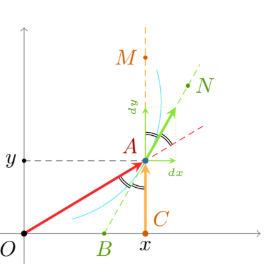

Воспользуемся векторным способом. Угол между векторами $OA$ и $BA$ равен углу между векторами $BA$ и $CA$. Координаты вектора $OA$ находятся элементарно: $OA = (x, y)$. Заметим, что прямая $BA$ является касательной к $y(x)$, поэтому вектор $BA$ должен быть сонаправлен вектору $δ = (dx, dy)$. Следовательно, при сравнении углов между векторами мы можем заменить вектор $BA$ на вектор $\delta$. А вместо вектора $CA$ возьмем сонаправленный с ним единичный вектор $e = (0, 1)$. Применим формулу для косинуса угла между векторами:

$$\require{cancel}\frac{OA \cdot \delta}{|OA| \cdot \cancel{|\delta|}} = \frac{e \cdot \delta}{|e| \cdot \cancel{|\delta|}}.$$

Длина вектора $OA$ равна $\sqrt{x^2 + y^2}$, вектор $e$ единичный. Вычислим скалярные произведения, используя известные координаты векторов:

$$OA \cdot \delta = xdx + ydy, e \cdot \delta = dy.$$

Подставляем эти соотношения в формулу косинуса угла между векторами и получаем дифференциальное уравнение, решение которого должно описывать искомую кривую:

$$\frac{xdx + ydy}{\sqrt{x^2 + y^2}} = dy.$$

Решим поставленную задачу в SymPy. Проверим найденное решение с помощью кода, который строит семейство отраженных лучей от заданной кривой.





1. Подключаем необходимые библиотеки.

In [ ]:
from sympy import *
from IPython.display import display
import numpy as np

2. Выведем уравнение семейства лучей, отраженных от некоторой кривой. Рассмотрим плоскость $OXY$, на этой плоскости - кривую $Y = y(X)$. Выберем на кривой точку с координатами $(x, y(x))$ и рассмотрим луч, падающий в эту точку вертикально сверху вниз. Отражение луча происходит относительно касательной к данной кривой в рассматриваемой точке. Пусть угол наклона касательной к оси $OX$ равен $\alpha$:

$$k = tg \alpha = y'(x).$$

Отраженный от такой касательной луч будет наклонен к оси $OX$ под углом $\phi = 90° + 2\alpha$, тогда

$$tg \phi = tg (90° + 2\alpha) = -ctg(2\alpha) = \frac{tg^2 \alpha - 1}{2 tg \alpha} = \frac{k^2 - 1}{2k}.$$

Таким образом, прямая, содержащая отраженный луч, наклонена к $OX$ под углом $\phi$ и проходит через точку с координатами $(x, y(x))$ и ее уравнение имеет вид

$$Y = tg \phi \cdot (X - x) + y(x) = Ax + B,$$

где $$A = tg \phi = \frac{k^2 - 1}{2k}, B = y(x) - Ax.$$

Так как $k$ зависит от $x$, уравнение для $Y$ представляет собой искомое параметрическое описание семейства отраженных лучей, в котором роль параметра играет символ $x$.

Определим символы $X$ и $Y$ для описания семейства кривых, параметр $x$ и функцию $y(x)$.

In [ ]:
X, Y, x = symbols("X Y x")  # создаем символьные переменные, так как sympy работает только с символами
y = Function("y")(x)  # просто задаем функцию y(x)

3. Вычисляем производную $k = y'(x)$, задаем коэффициенты $A$ и $B$.

In [ ]:
k = diff(y, x)  # производная y по x
A = (k ** 2 - 1) / (2 * k)
B = simplify(y - x * A)  # упрощает выражение
display(A, B)

(Derivative(y(x), x)**2 - 1)/(2*Derivative(y(x), x))

-x*Derivative(y(x), x)/2 + x/(2*Derivative(y(x), x)) + y(x)

4. Записываем уравнение семейства отраженных лучей.

In [ ]:
fam = Eq(Y, A * X + B)  # создает уравнение вида Y = AX + B
display(fam)

Eq(Y, X*(Derivative(y(x), x)**2 - 1)/(2*Derivative(y(x), x)) - x*Derivative(y(x), x)/2 + x/(2*Derivative(y(x), x)) + y(x))

5. Построим семейство лучей, отраженных от нижней единичной полуокружности. Задаем уравнение ```f1``` такой кривой и подставляем его вместо ```f``` в уравнение ```fam```. Метод ```doit``` применяется для вычисления всех производных.

In [ ]:
f1 = -sqrt(1 - x ** 2)  # уравнение нижней половины полуокружности
fam1 = simplify(fam.subs(y, f1).doit())
'''
fam - уравнение семейства отраженных лучей
fam.subs(y, f1) заменяет в выражении fam все вхождения y на конкретное выражение f1
.doit() явно вычисляет "отложенные на потом" операции, так как в sympy операция не вычисляются сразу и остается в виде Derivative(...)
simplify - упрощение выражения
'''
# fam 1 - уравнение конкретного семейства прямых
display(fam1)

Eq(Y, (2*X*x**2 - X - x)/(2*x*sqrt(1 - x**2)))

6. Строим график полученного семейства ```fam1``` и поверх него исходную полуокружность. Внутри окружности видна кривая, образованная сгущением прямых линий - каустика. **Каустика** - это особая линия или поверхность, вблизи которой резко возрастает интенсивность освещения за счет отражения или преломления потока световых лучей некоторой поверхностью или телом. Математически каустика представляет собой огибающую семейства прямых.

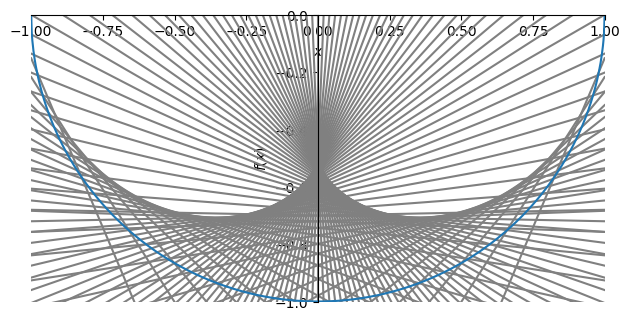

In [ ]:
p1 = plot(xlim=(-1, 1), ylim=(-1, 0), aspect_ratio=(1, 1), show=False)  # постепенно накапливаем линии на графике, покажем только в конце. aspect_ratio - одинаковый масштаб по осям
for x0 in np.arange(-0.98, 1, 0.02):  # каждый шаг рисует один луч, падающий в x0
  l = fam1.rhs.subs(x, x0)  # fam1 - уравнение вида Y = выражение(X, x); .rhs - берем правую часть (Y), l - итоговый луч
  p=plot(l, (X, -1, 1), line_color='gray', show=False)
  p1.extend(p)  # добавляем луч в общий контейнер
p1.extend(plot(f1, (x, -1, 1), show=False))  # добавляем кривую
p1.show()

7. Заменим в выражениях ```A``` и ```B``` символ функции ```f``` на уравнение полуокружности ```f1``` и вычислим параметрическое уравнение огибающей семейства ```fam1```.

In [ ]:
A1 = A.subs(y, f1).doit()
B1 = B.subs(y, f1).doit()
XC = simplify(- diff(B1, x) / diff(A1, x))
YC = simplify(A1 * XC + B1)
display(XC, YC)

x**3

(2*x**4 - x**2 - 1)/(2*sqrt(1 - x**2))

8. Добавляем каустику $(XC, YC)$ к построенному ранее графику ```p1```. Найденная параметрическая кривая называется нефроидой и является частным случаем эпициклоиды.

<lambdifygenerated-203>:2: RuntimeWarning: invalid value encountered in scalar divide
  return (1/2)*(2*x**4 - x**2 - 1)/sqrt(1 - x**2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2480: RuntimeWarning: invalid value encountered in wrapper_func (vectorized)
  outputs = ufunc(*inputs)


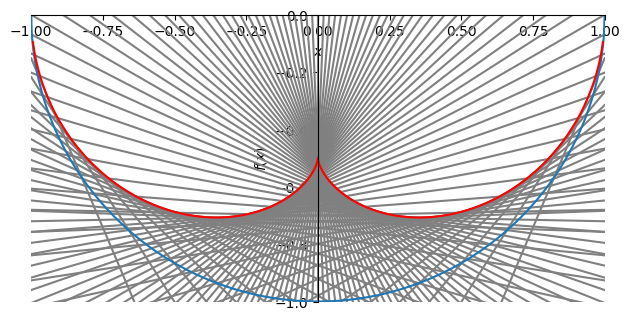

In [ ]:
p2 = plot(xlim=(-1, 1), ylim=(-1, 0), aspect_ratio=(1, 1), show=False)  # контейнер для графиков
p = plot_parametric((XC, YC), (x, -1, 1), line_color='red', show=False)  # построение параметрического графика каустики. x меняется от -1 до 1.
p2.extend(p1)  # добавляем лучи и окружность в контейнер
p2.extend(p)  # добавляем акустику в контейнер
p2.show()

9. Определяем символы для дифференциалов и строим векторы $OA$, $\delta$ и $e$ с помощью кортежей SymPy.

In [ ]:
dx, dy = symbols('dx dy')
OA = Tuple(x, y)
delta = Tuple(dx, dy)
e = Tuple(0, 1)
display(OA, delta, e)

(x, y(x))

(dx, dy)

(0, 1)

10. Определяем функцию для скалярного произведения двух двумерных векторов и тестируем ее.

In [ ]:
def dot(u, v):
  return u[0] * v[0] + u[1] * v[1]

display(dot(OA, delta))

dx*x + dy*y(x)

11. Определяем функцию для вычисления длины заданного вектора, тестируем ее.

In [ ]:
def length(u):
  return sqrt(dot(u, u))

display(length(OA))

sqrt(x**2 + y(x)**2)

12. Составляем искомое дифференциальное уравнение.

In [ ]:
ode = Eq(dot(OA, delta) / length(OA),
         dot(e, delta) / length(e))

display(ode)

Eq((dx*x + dy*y(x))/sqrt(x**2 + y(x)**2), dy)

13. Перейдем от уравнения в дифференциалах к уравнению с производной.

In [ ]:
ode1 = ode.subs({dx: 1, dy: diff(y, x)})

display(ode1)

Eq((x + y(x)*Derivative(y(x), x))/sqrt(x**2 + y(x)**2), Derivative(y(x), x))

14. Проверим тип уравнения (2-я строка вывода показывает, что это уравнение в полных дифференциалах).

In [ ]:
classify_ode(ode1, y)

('factorable',
 '1st_exact',
 '1st_homogeneous_coeff_best',
 '1st_homogeneous_coeff_subs_indep_div_dep',
 '1st_homogeneous_coeff_subs_dep_div_indep',
 '1st_power_series',
 'lie_group',
 '1st_exact_Integral',
 '1st_homogeneous_coeff_subs_indep_div_dep_Integral',
 '1st_homogeneous_coeff_subs_dep_div_indep_Integral')

15. Судя по второй строке вывода, тип уравнения - уравнение в полных дифференциалах.

Решим уравнение ```ode1``` как уравнение в полных дифференциалах, используя подсказку ```1st_exact```.

In [ ]:
dsol = dsolve(ode1, y, hint='1st_exact')

display(dsol)

Eq(y(x), -C1/2 + x**2/(2*C1))

16. Найденное решение оказалось квадратичной функцией. Следовательно, искомые кривые - параболы. Построим семейство таких парабол. Так как все они имеют общую точку фокуса, данное семейство называется семейством конфокальных парабол.

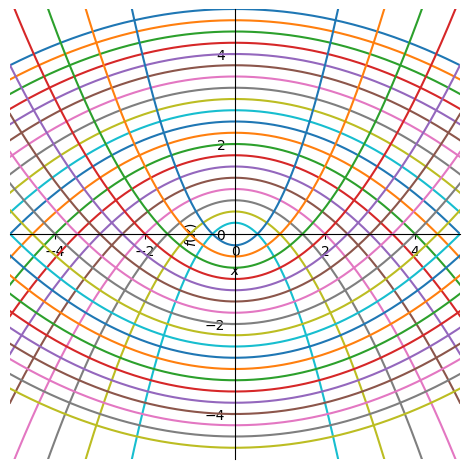

In [ ]:
C1 = symbols("C1")
p3 = plot(xlim=(-5, 5), ylim=(-5, 5),
          aspect_ratio=(1, 1),
          show=False)

for c in np.arange(-10, 10, 0.5):
    if abs(c) < 1e-9:  # пропускаем c = 0
        continue
    y_expr = dsol.rhs.subs(C1, c)
    p = plot(y_expr, (x, -5, 5), show=False)
    p3.extend(p)

p3.show()

17. Выберем одну из найденных парабол (например $C_1 = 1$) и построим семейство отраженных от нее лучей, чтобы проверить, что эти лучи проходят через начало координат. Определим уравнение данной параболы и сохраним его в ```f2```.

In [ ]:
f2 = dsol.rhs.subs(C1, 1)

display(f2)

x**2/2 - 1/2

18. Подставим эту формулу в общее уравнение ```fam``` семейства отраженных лучей.

In [ ]:
fam2 = fam.subs(y, f2).doit()

display(fam2)

Eq(Y, X*(x**2 - 1)/(2*x))

19. Построим на одном графике параболу ```f2``` и порожденное ею семейство прямых ```fam2```.

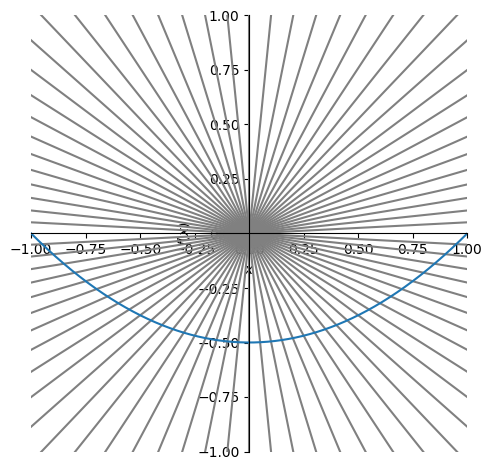

In [ ]:
p4 = plot(xlim=(-1, 1), ylim=(-1, 1), aspect_ratio=(1, 1), show=False)
for x0 in np.arange(-0.95, 1, 0.05):
  l = fam2.rhs.subs(x, x0)
  p = plot(l, (X, -1, 1), line_color='gray', show=False)
  p4.extend(p)
p4.extend(plot(f2, (x, -1, 1), show=False))
p4.show()

Результат построения наглядно показывает фокусирование отраженных лучей в начале координат.

# УПРАЖНЕНИЕ 1. ВАРИАНТ 1

Определить уравнение $2xydx + (x^2 - y^2)dy = 0$, проверить его тип и решить.

In [54]:
from sympy import *
from IPython.display import display

x = symbols('x')
y = Function('y')(x)

ode = Eq(2 * x * y + (x**2 - y**2) * diff(y, x), 0)

display(classify_ode(ode, y))  # выводим, что у нас ур-ие в полных дифференциалах
print()

sol_exact = dsolve(ode, y, hint='1st_exact', simplify=False)
display(sol_exact)

# Решения с другими подсказками
sol_homog = dsolve(ode, y, hint='1st_homogeneous_coeff_best', simplify=False)
display(sol_homog)

sol_lie = dsolve(ode, y, hint='lie_group', simplify=False)
display(sol_lie)

('factorable',
 '1st_exact',
 '1st_homogeneous_coeff_best',
 '1st_homogeneous_coeff_subs_indep_div_dep',
 '1st_homogeneous_coeff_subs_dep_div_indep',
 '1st_power_series',
 'lie_group',
 '1st_exact_Integral',
 '1st_homogeneous_coeff_subs_indep_div_dep_Integral',
 '1st_homogeneous_coeff_subs_dep_div_indep_Integral')

           3        
 2        y (x)     
x ⋅y(x) - ───── = C₁
            3       

                         ⎛   2     ⎞
                         ⎜3⋅x      ⎟
                      log⎜───── - 1⎟
                         ⎜ 2       ⎟
                         ⎝y (x)    ⎠
log(y(x)) = log(C₁) - ──────────────
                            3       

⎡                                                           __________________ ↪
⎢                                                          ╱             _____ ↪
⎢                                                         ╱             ╱      ↪
⎢                                                        ╱            ╲╱  2624 ↪
⎢                              2                      3 ╱    -81⋅C₁ + ──────── ↪
⎢                           3⋅x                       ╲╱                       ↪
⎢y(x) = - ───────────────────────────────────────── - ──────────────────────── ↪
⎢               ___________________________________                       3    ↪
⎢              ╱             _____________________                             ↪
⎢             ╱             ╱         2         6                              ↪
⎢            ╱            ╲╱  26244⋅C₁  - 2916⋅x                               ↪
⎢         3 ╱    -81⋅C₁ + ────────────────────────                             ↪
⎣         ╲╱                

# УПРАЖНЕНИЕ 3. ВАРИАНТ 1

Построить каустику отражения, порожденную кривой $y(x) = x^3$, для случая параллельного пучка лучей, падающих на эту кривую сверху вниз.

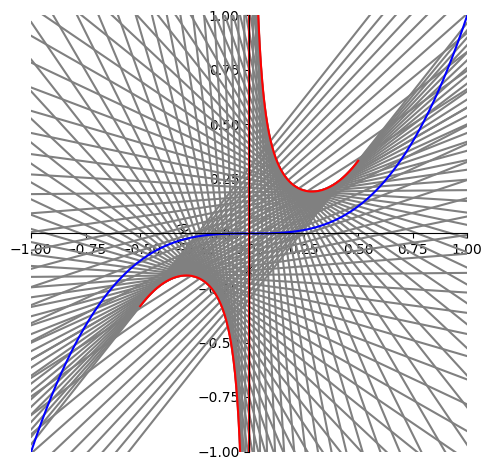

In [37]:
from sympy import *
from IPython.display import display

X, Y, x = symbols("X Y x")
y = Function("y")(x)

k = diff(y, x)
A = (k**2 - 1) / (2*k)
B = simplify(y - x*A)

fam = Eq(Y, A*X + B)  # уравнение семейства прямых

f1 = x**3
fam1 = simplify(fam.subs(y, f1).doit())

p1 = plot(xlim=(-1, 1), ylim=(-1, 1),
          aspect_ratio=(1, 1), show=False)

for x0 in np.arange(-0.98, 1, 0.02):
    l = fam1.rhs.subs(x, x0)
    p = plot(l, (X, -1, 1), line_color="gray", show=False)
    p1.extend(p)

p1.extend(plot(f1, (x, -1, 1), line_color="blue", show=False))  # добавляем исходную кривую

# каустика
A1 = A.subs(y, f1).doit()
B1 = B.subs(y, f1).doit()

XC = simplify(-diff(B1, x) / diff(A1, x))
YC = simplify(A1 * XC + B1)

p2 = plot(xlim=(-1, 1), ylim=(-1, 1),
          aspect_ratio=(1, 1), show=False)

p = plot_parametric((XC, YC), (x, -1, 1),
                            line_color="red", show=False)

p2.extend(p1)  # добавляем лучи и кривую
p2.extend(p)  # добавляем каустику
p2.show()

# УПРАЖНЕНИЕ 11. ВАРИАНТ 2

Вывести уравнение каустики для общего случая, когда лучи, исходящие из начала координат, падают снизу на заданную кривую $y(x) = (x - 1)^2 (x + 1)$, и применить полученную формулу для получения каустики.

Уравнение каустики:


  ⎛   8      7      6       5       4       3      2    ⎞
2⋅⎝6⋅x  - 6⋅x  + 9⋅x  - 36⋅x  + 21⋅x  + 12⋅x  - 9⋅x  - 1⎠
─────────────────────────────────────────────────────────
    7      6       5       4       3       2             
 6⋅x  - 5⋅x  + 12⋅x  - 51⋅x  + 28⋅x  + 24⋅x  - 24⋅x + 2  

  ⎛     10       9      8       7       6       5       4       3       2      ↪
2⋅⎝- 6⋅x   + 20⋅x  - 6⋅x  - 48⋅x  + 42⋅x  + 36⋅x  - 57⋅x  + 12⋅x  + 18⋅x  - 12 ↪
────────────────────────────────────────────────────────────────────────────── ↪
                  7      6       5       4       3       2                     ↪
               6⋅x  - 5⋅x  + 12⋅x  - 51⋅x  + 28⋅x  + 24⋅x  - 24⋅x + 2          ↪

↪       ⎞
↪ ⋅x + 1⎠
↪ ───────
↪        
↪        

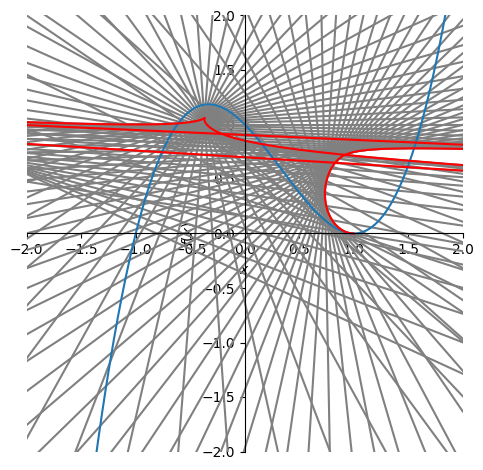

In [93]:
from sympy import *
from IPython.display import display

X, Y, x = symbols('X Y x')
y = Function('y')(x)

k = diff(y, x)

tan_theta = y / x
tan_alpha = k
tan_2alpha = 2*tan_alpha/(1 - tan_alpha**2)

A = (tan_2alpha - tan_theta) / (1 + tan_2alpha * tan_theta)
B = simplify(y - x * A)

fam = Eq(Y, A * X + B)

f1 = (x-1)**2 * (x+1)
k1 = diff(f1, x)

fam1 = simplify(fam.subs(y, f1).doit())

# Строим семейство лучей и кривую
p1 = plot(xlim=(-2, 2), ylim=(-2, 2), aspect_ratio=(1,1), show=False)
for x0 in np.arange(-0.98, 1, 0.02):
    l = fam1.rhs.subs(x, x0)
    p = plot(l, (X, -2, 2), line_color='gray', show=False)
    p1.extend(p)
p1.extend(plot(f1, (x, -2, 2), show=False))

# каустика
A1 = A.subs(y, f1).doit()
B1 = B.subs(y, f1).doit()
XC = simplify(- diff(B1, x) / diff(A1, x))
YC = simplify(A1 * XC + B1)

print('Уравнение каустики:')
display(XC, YC)

# Добавляем каустику
p2 = plot(xlim=(-2, 2), ylim=(-2, 2), aspect_ratio=(1,1), show=False)
p = plot_parametric((XC, YC), (x, -1, 1), line_color='red', show=False)
p2.extend(p1)
p2.extend(p)
p2.show()

# УПРАЖНЕНИЕ 13

Поставить и решить с помощью SymPy задачу нахождения такой кривой $y(x)$, после отражения от которой все лучи, исходящие из заданной точки $F1$, проходят через другую заданную точку $F2$.

Каноническое решение (семейство эллипсов и гипербол):


 2        2    
y (x)    x     
────── + ── = 1
     2   A     
A - c          

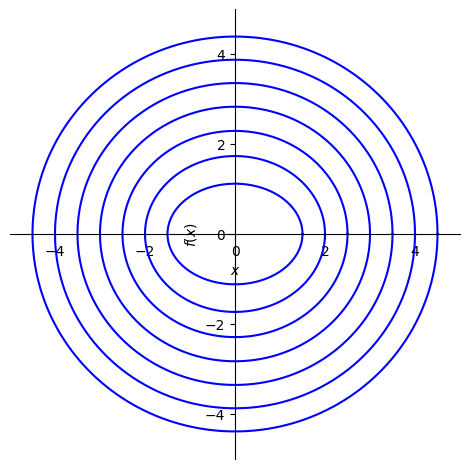

ValueError: Too many free symbols.
Expected 1 free symbols.
Received 2: {Y, X_plot}

In [101]:
from sympy import *
import numpy as np

# ---------- 1. Символьный вывод: каноническое решение ----------
x_sym = Symbol('x')
c_sym = Symbol('c')
y_sym = Function('y')(x_sym)
p = Symbol('p')
C1 = Symbol('C_1')
A = Symbol('A')

# Дифференциальное уравнение (вывод опущен для краткости, но он есть в вашем коде)
ode_p = x_sym * y_sym * p**2 + (x_sym**2 - y_sym**2 - c_sym**2) * p - x_sym * y_sym

# Переход к уравнению Клеро через u=x^2, v=y^2
u, v, dv_du = symbols('u v dv_du', positive=True)
ode_uv = ode_p.subs({p: sqrt(u/v)*dv_du, x_sym: sqrt(u), y_sym: sqrt(v)})
ode_uv = simplify(ode_uv * sqrt(v/u))
v_expr = solve(ode_uv, v)[0]
v_sol = v_expr.subs(dv_du, C1)
canonical_form = Eq(x_sym**2 / A + y_sym**2 / (A - c_sym**2), 1)

print("Каноническое решение (семейство эллипсов и гипербол):")
display(canonical_form)

# ---------- 2. Построение семейства конфокальных эллипсов (рис. 7) ----------
c_num = 1   # фокусы в (-1,0) и (1,0)
Xvar, t = symbols('Xvar t')
p3 = plot(xlim=(-5, 5), ylim=(-5, 5), aspect_ratio=(1,1), show=False)
for a_val in np.arange(1.5, 5, 0.5):
    b_val = sqrt(a_val**2 - c_num**2)
    x_e = a_val * cos(t)
    y_e = b_val * sin(t)
    p_ell = plot_parametric((x_e, y_e), (t, 0, 2*pi), line_color='blue', show=False)
    p3.extend(p_ell)
p3.show()

# ---------- 3. Построение лучей для конкретного эллипса (рис. 8) ----------
# Выбираем эллипс с a=2
a0 = 2
b0 = sqrt(a0**2 - c_num**2)
F1 = (-c_num, 0)
F2 = (c_num, 0)

# Функция для верхней половины эллипса (y >= 0)
f1 = sqrt(b0**2 * (1 - Xvar**2 / a0**2))
# Производная
f1_prime = diff(f1, Xvar)

# Семейство лучей для точечного источника в начале координат (в методичке для рис. 8? но у вас лучи из F1, а не из 0)
# Нам нужно семейство прямых, проходящих через F1 и точку эллипса, а также отражённых в F2.
# Сделаем просто: для каждого x0 строим две прямые.

p4 = plot(xlim=(-3, 3), ylim=(-3, 3), aspect_ratio=(1,1), show=False)

# Рисуем эллипс (верхняя половина синим, нижнюю можно добавить)
p_ell_top = plot(f1, (Xvar, -a0, a0), line_color='blue', show=False)
p_ell_bottom = plot(-f1, (Xvar, -a0, a0), line_color='blue', show=False)
p4.extend(p_ell_top)
p4.extend(p_ell_bottom)

# Рисуем лучи: из F1 в точку и из точки в F2
X_plot = symbols('X_plot')
for x0 in np.linspace(-a0+0.05, a0-0.05, 15):
    y0 = b0 * sqrt(1 - (x0/a0)**2)
    # Падающий луч: через F1 и (x0, y0)
    if abs(x0 - F1[0]) > 1e-9:
        k1 = (y0 - F1[1]) / (x0 - F1[0])
        line1 = Eq(Y, k1*(X_plot - x0) + y0)
    else:
        line1 = Eq(X_plot, F1[0])
    # Отражённый луч: через (x0,y0) и F2
    if abs(x0 - F2[0]) > 1e-9:
        k2 = (F2[1] - y0) / (F2[0] - x0)
        line2 = Eq(Y, k2*(X_plot - x0) + y0)
    else:
        line2 = Eq(X_plot, F2[0])
    p_line1 = plot(line1, (X_plot, -3, 3), line_color='gray', show=False)
    p_line2 = plot(line2, (X_plot, -3, 3), line_color='gray', show=False)
    p4.extend(p_line1)
    p4.extend(p_line2)

# Каустика – второй фокус (точка)
p_caustic = plot_parametric((F2[0], 0), (X_plot, 0, 1), line_color='red', show=False)
p4.extend(p_caustic)
p4.show()

Дифференциальное уравнение отражающей кривой:


 2            ⎛   2    2    2   ⎞             
p ⋅x⋅y(x) + p⋅⎝- c  + x  - y (x)⎠ - x⋅y(x) = 0


Каноническое решение (семейство эллипсов и гипербол):


 2        2    
y (x)    x     
────── + ── = 1
     2   A     
A - c          

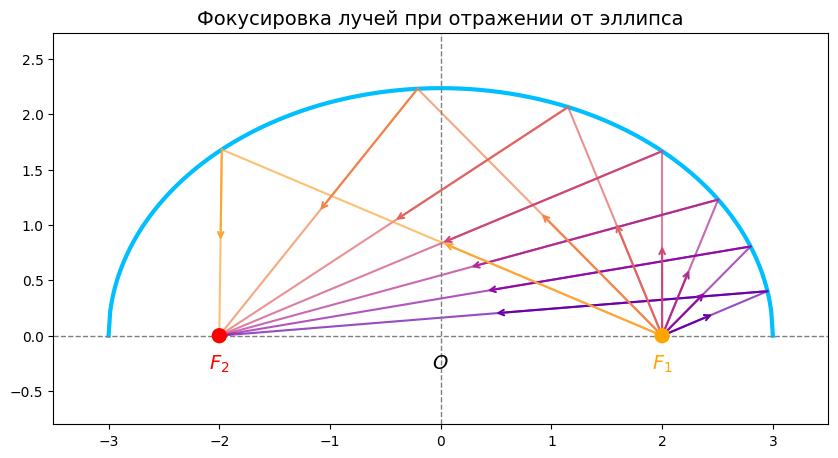

In [ ]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

x_sym = Symbol('x')
c_sym = Symbol('c')
y_sym = Function('y')(x_sym)
p = Symbol('p')  # dy/dx
C1 = Symbol('C_1')

# Векторы: F1(c, 0), F2(-c, 0), M(x, y), касательная tau(1, p)
r1 = Matrix([x_sym - c_sym, y_sym])
r2 = Matrix([-c_sym - x_sym, -y_sym])
tau = Matrix([1, p])

# Дифференциальное уравнение из закона отражения
ode_p = x_sym * y_sym * p**2 + (x_sym**2 - y_sym**2 - c_sym**2) * p - x_sym * y_sym
print("Дифференциальное уравнение отражающей кривой:")
display(Eq(ode_p, 0))
print()

# Переход к уравнению Клеро через замену u = x^2, v = y^2
u, v, dv_du = symbols('u v dv_du', positive=True)
ode_uv = ode_p.subs({p: sqrt(u/v)*dv_du, x_sym: sqrt(u), y_sym: sqrt(v)})
ode_uv = simplify(ode_uv * sqrt(v/u))

# Выбираем первый элемент из списка решений [0]
v_expr = solve(ode_uv, v)[0]

# Решение уравнения Клеро и каноническая форма
v_sol = v_expr.subs(dv_du, C1)
A = Symbol('A')
canonical_form = Eq(x_sym**2 / A + y_sym**2 / (A - c_sym**2), 1)

print("Каноническое решение (семейство эллипсов и гипербол):")
display(canonical_form)


# Параметры геометрии (выберем конкретный эллипс для графика)
c = 2.0      # Половина фокусного расстояния (фокусы в -2 и 2)
a = 3.0      # Большая полуось эллипса
b = np.sqrt(a**2 - c**2) # Малая полуось эллипса

# Точки фокусов
F1 = np.array([c, 0])
F2 = np.array([-c, 0])

# Настройка графика
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Генерация точек эллипса (верхняя дуга)
x_ell = np.linspace(-a, a, 400)
y_ell = b * np.sqrt(1 - (x_ell / a)**2)
ax.plot(x_ell, y_ell, label='Отражающая кривая (Эллипс)', color='deepskyblue', linewidth=3)

# Отмечаем фокусы (исправленный формат координат для scatter)
ax.scatter([F1[0], F2[0]], [F1[1], F2[1]], color=['orange', 'red'], s=100, zorder=5)
ax.text(c, -0.3, '$F_1$', fontsize=14, color='orange', ha='center')
ax.text(-c, -0.3, '$F_2$', fontsize=14, color='red', ha='center')
ax.text(0, -0.3, '$O$', fontsize=14, color='black', ha='center')

# Строим сетку падающих и отраженных лучей
angles = np.linspace(0.4, np.pi - 0.4, 7)
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(angles)))

for angle, color in zip(angles, colors):
    dx, dy = np.cos(angle), np.sin(angle)

    # Расчет точки пересечения луча из F1 с эллипсом
    A_quad = (dx / a)**2 + (dy / b)**2
    B_quad = 2 * c * dx / (a**2)
    C_quad = (c / a)**2 - 1

    roots = np.roots([A_quad, B_quad, C_quad])
    t = max(roots)

    # Координаты точки отражения M на эллипсе
    M = F1 + t * np.array([dx, dy])

    # Рисуем линии лучей
    ax.plot([F1[0], M[0]], [F1[1], M[1]], color=color, alpha=0.7, linewidth=1.5)
    ax.plot([M[0], F2[0]], [M[1], F2[1]], color=color, alpha=0.7, linewidth=1.5)

    # Добавляем стрелочки направления движения света
    ax.annotate('', xy=((F1[0]+M[0])/2, (F1[1]+M[1])/2), xytext=(F1[0], F1[1]),
                 arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
    ax.annotate('', xy=((M[0]+F2[0])/2, (M[1]+F2[1])/2), xytext=(M[0], M[1]),
                 arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

# Оформление осей координат
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.xlim_val = (-a - 0.5, a + 0.5)
ax.ylim_val = (-0.8, b + 0.5)
ax.set_xlim(ax.xlim_val)
ax.set_ylim(ax.ylim_val)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Фокусировка лучей при отражении от эллипса', fontsize=14)
plt.show()
